# LAB 05: HOG-Based Industrial Defect Detection and Classification
**Pipeline:** Image → Preprocessing → HOG Feature Extraction → ML Classifier (SVM / Random Forest) → Defective / Non-Defective → ACCEPT / REJECT



## 0. Setup

In [1]:
!pip -q install scikit-image kagglehub

In [2]:
import os, re, glob, random, time, warnings
import numpy as np, pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import Parallel, delayed
import joblib

from skimage.feature import hog
from skimage import exposure

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, ConfusionMatrixDisplay)

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED); np.random.seed(SEED)

# ---- Configuration ----
IMG_SIZE     = 128          # common resolution (original NEU images are 200x200)
NORMAL_CLASS = "crazing"    # class treated as Non-Defective for binary task (see note above)
CLASS_NAMES  = ["crazing", "inclusion", "patches", "pitted_surface", "rolled-in_scale", "scratches"]

## 1. Load and inspect the dataset

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sovitrath/neu-steel-surface-defect-detect-trainvalid-split")

print("Path to dataset files:", path)

DATA_DIR = path  # used by the rest of the notebook

Using Colab cache for faster access to the 'neu-steel-surface-defect-detect-trainvalid-split' dataset.
Path to dataset files: /kaggle/input/neu-steel-surface-defect-detect-trainvalid-split


In [4]:
EXTS = (".jpg", ".jpeg", ".png", ".bmp")

def label_from_path(p):
    name = os.path.basename(p).lower()
    for c in CLASS_NAMES:                       # filenames look like  crazing_12.jpg
        if name.startswith(c):
            return c
    parent = os.path.basename(os.path.dirname(p)).lower()   # fallback: class folder
    return parent if parent in CLASS_NAMES else None

all_paths = [p for p in glob.glob(os.path.join(DATA_DIR, "**", "*"), recursive=True)
             if p.lower().endswith(EXTS)]
records = [(p, label_from_path(p)) for p in all_paths]
df = pd.DataFrame(records, columns=["path", "label"]).dropna().reset_index(drop=True)

print("Total images:", len(df))
print(df["label"].value_counts().sort_index())
sample = cv2.imread(df.path[0])
print("Example image shape:", sample.shape)

Total images: 1800
label
crazing            300
inclusion          300
patches            300
pitted_surface     300
rolled-in_scale    300
scratches          300
Name: count, dtype: int64
Example image shape: (200, 200, 3)


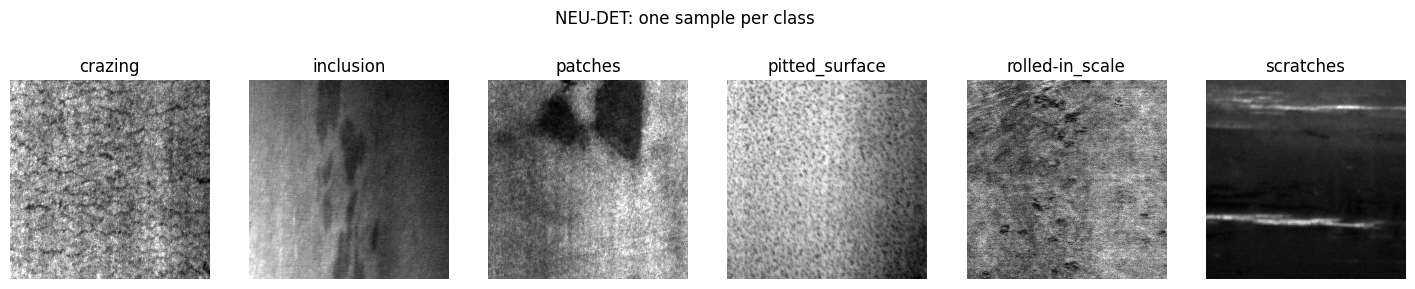

In [5]:
# Show 1 example of each class
fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(18, 3.5))
for ax, c in zip(axes, CLASS_NAMES):
    p = df[df.label == c].path.iloc[0]
    ax.imshow(cv2.imread(p, 0), cmap="gray"); ax.set_title(c); ax.axis("off")
plt.suptitle("NEU-DET: one sample per class"); plt.show()

## 2–3. Preprocessing: resize + grayscale

In [6]:
def preprocess(img):
    """BGR/gray image -> grayscale -> resized IMG_SIZE x IMG_SIZE (uint8)."""
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

def load_gray(p):
    return preprocess(cv2.imread(p, cv2.IMREAD_COLOR))

X_img = np.array(Parallel(n_jobs=-1)(delayed(load_gray)(p) for p in df.path))
y_multi = df.label.map({c: i for i, c in enumerate(CLASS_NAMES)}).values
y_bin   = (df.label != NORMAL_CLASS).astype(int).values      # 0 = normal, 1 = defective
print(X_img.shape, "| binary counts:", np.bincount(y_bin))

(1800, 128, 128) | binary counts: [ 300 1500]


In [7]:
# Stratified 70 / 15 / 15 split (train / validation / test), stratified on the 6 classes
idx = np.arange(len(df))
tr, tmp = train_test_split(idx, test_size=0.30, stratify=y_multi, random_state=SEED)
va, te  = train_test_split(tmp, test_size=0.50, stratify=y_multi[tmp], random_state=SEED)
print("train/val/test:", len(tr), len(va), len(te))

train/val/test: 1260 270 270


## 4–5. HOG feature extraction and visualisation


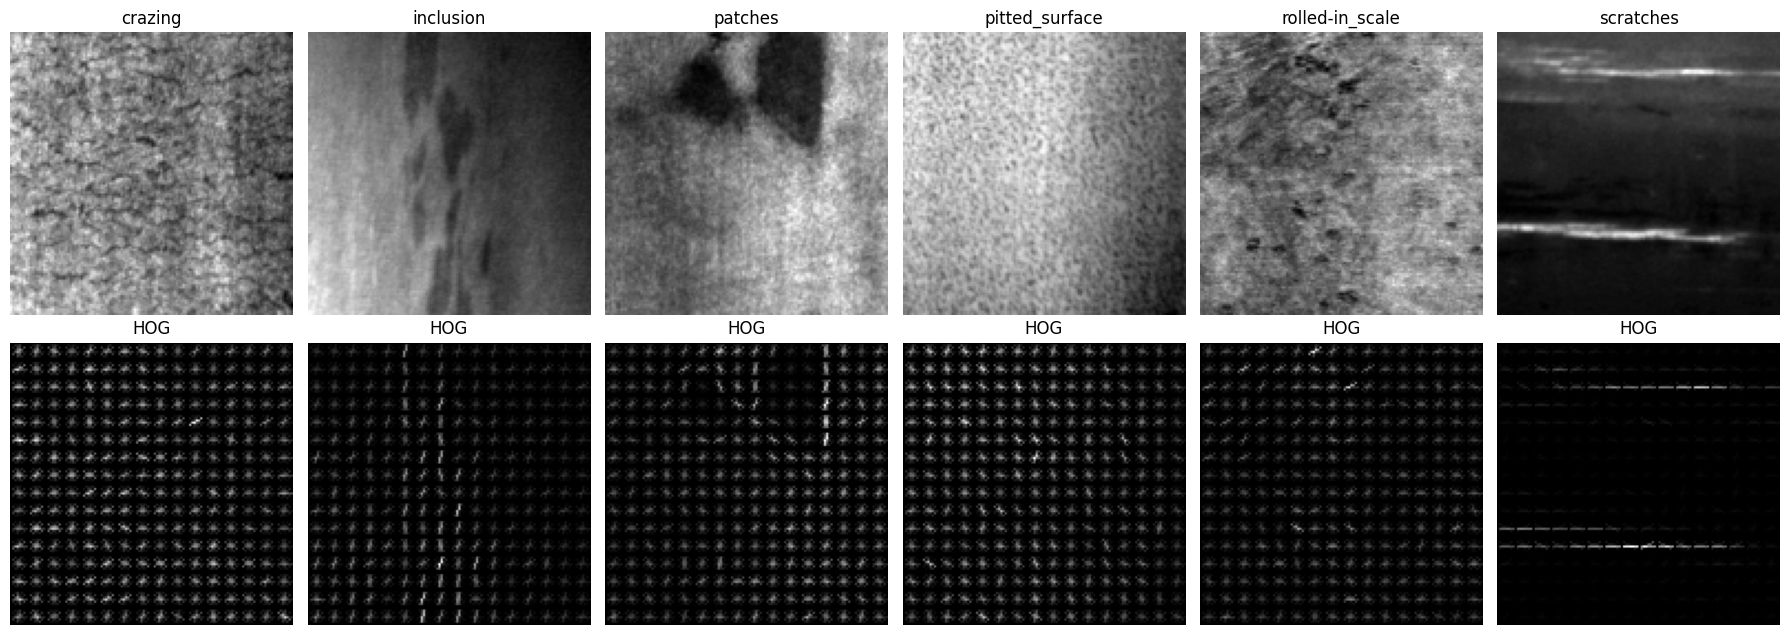

HOG vector length (8x8 cells, 9 orient.): 8100


In [8]:
def hog_feat(img, cell=8, ori=9, block=2):
    return hog(img, orientations=ori, pixels_per_cell=(cell, cell),
               cells_per_block=(block, block), block_norm="L2-Hys", feature_vector=True)

def extract_hog(X, cell=8, ori=9):
    return np.array(Parallel(n_jobs=-1)(delayed(hog_feat)(x, cell, ori) for x in X))

# Visualise HOG for one image of each class
fig, axes = plt.subplots(2, len(CLASS_NAMES), figsize=(18, 6.5))
for j, c in enumerate(CLASS_NAMES):
    i = np.where(y_multi == j)[0][0]
    _, hog_img = hog(X_img[i], orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2),
                     visualize=True, block_norm="L2-Hys")
    hog_img = exposure.rescale_intensity(hog_img, in_range=(0, hog_img.max() + 1e-9))
    axes[0, j].imshow(X_img[i], cmap="gray"); axes[0, j].set_title(c); axes[0, j].axis("off")
    axes[1, j].imshow(hog_img, cmap="gray");  axes[1, j].set_title("HOG"); axes[1, j].axis("off")
plt.tight_layout(); plt.show()
print("HOG vector length (8x8 cells, 9 orient.):", len(hog_feat(X_img[0])))

## 6–8. Classifiers: HOG + SVM and HOG + Random Forest

In [9]:
def make_svm(prob=False):
    return make_pipeline(StandardScaler(),
                         SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced",
                             probability=prob, random_state=SEED))

def make_rf():
    return make_pipeline(StandardScaler(),
                         RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                                n_jobs=-1, random_state=SEED))

def get_metrics(y, p, avg):
    return dict(Accuracy=accuracy_score(y, p),
                Precision=precision_score(y, p, average=avg, zero_division=0),
                Recall=recall_score(y, p, average=avg, zero_division=0),
                F1=f1_score(y, p, average=avg, zero_division=0))

# Baseline: cell 8x8, 9 orientations
CELL0, ORI0 = 8, 9
F = extract_hog(X_img, CELL0, ORI0)
print("Feature matrix:", F.shape)

rows = []
trained = {}
for task, y, avg in [("Binary", y_bin, "binary"), ("Multi-class", y_multi, "macro")]:
    for name, mk in [("HOG + SVM", make_svm), ("HOG + Random Forest", make_rf)]:
        t0 = time.time()
        m = mk().fit(F[tr], y[tr])
        pred = m.predict(F[te])
        trained[(task, name)] = (m, pred)
        rows.append({"Task": task, "Model": name, **get_metrics(y[te], pred, avg),
                     "Train+predict (s)": round(time.time() - t0, 1)})
results_df = pd.DataFrame(rows).round(4)
results_df

Feature matrix: (1800, 8100)


,Task,Model,Accuracy,Precision,Recall,F1,Train+predict (s)
0,Binary,HOG + SVM,0.9778,0.9824,0.9911,0.9867,6.9
1,Binary,HOG + Random Forest,0.8556,0.8550,0.9956,0.9199,28.7
2,Multi-class,HOG + SVM,0.8593,0.8610,0.8593,0.8566,16.7
3,Multi-class,HOG + Random Forest,0.7630,0.7771,0.7630,0.7483,31.9


## 9–10. Confusion matrices, classification reports, accuracy / precision / recall / F1

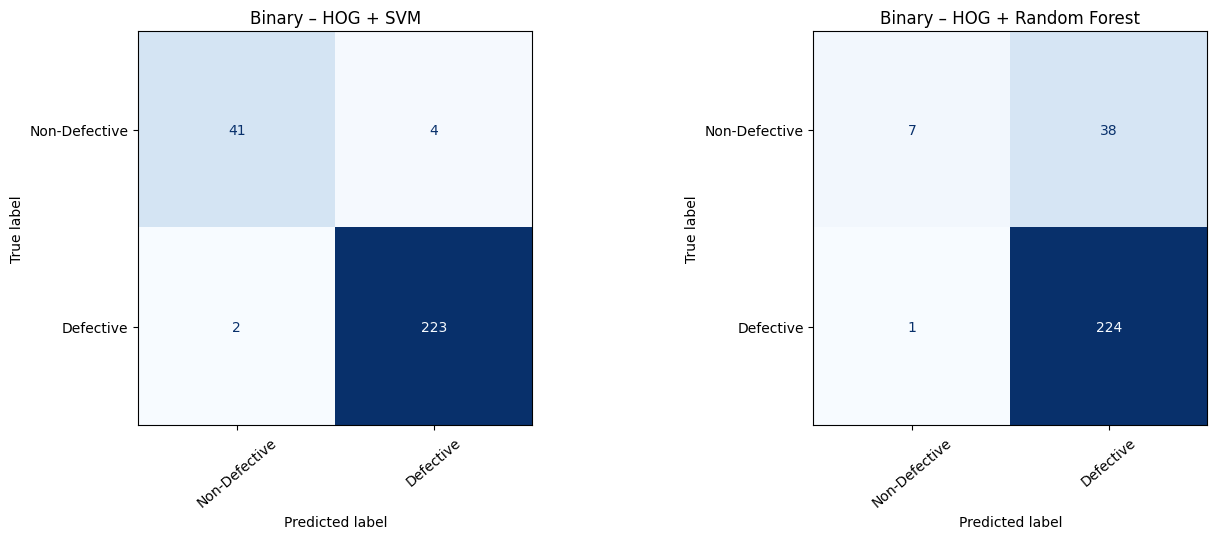


===== Binary | HOG + SVM =====
               precision    recall  f1-score   support

Non-Defective     0.9535    0.9111    0.9318        45
    Defective     0.9824    0.9911    0.9867       225

     accuracy                         0.9778       270
    macro avg     0.9679    0.9511    0.9593       270
 weighted avg     0.9776    0.9778    0.9776       270


===== Binary | HOG + Random Forest =====
               precision    recall  f1-score   support

Non-Defective     0.8750    0.1556    0.2642        45
    Defective     0.8550    0.9956    0.9199       225

     accuracy                         0.8556       270
    macro avg     0.8650    0.5756    0.5920       270
 weighted avg     0.8583    0.8556    0.8106       270



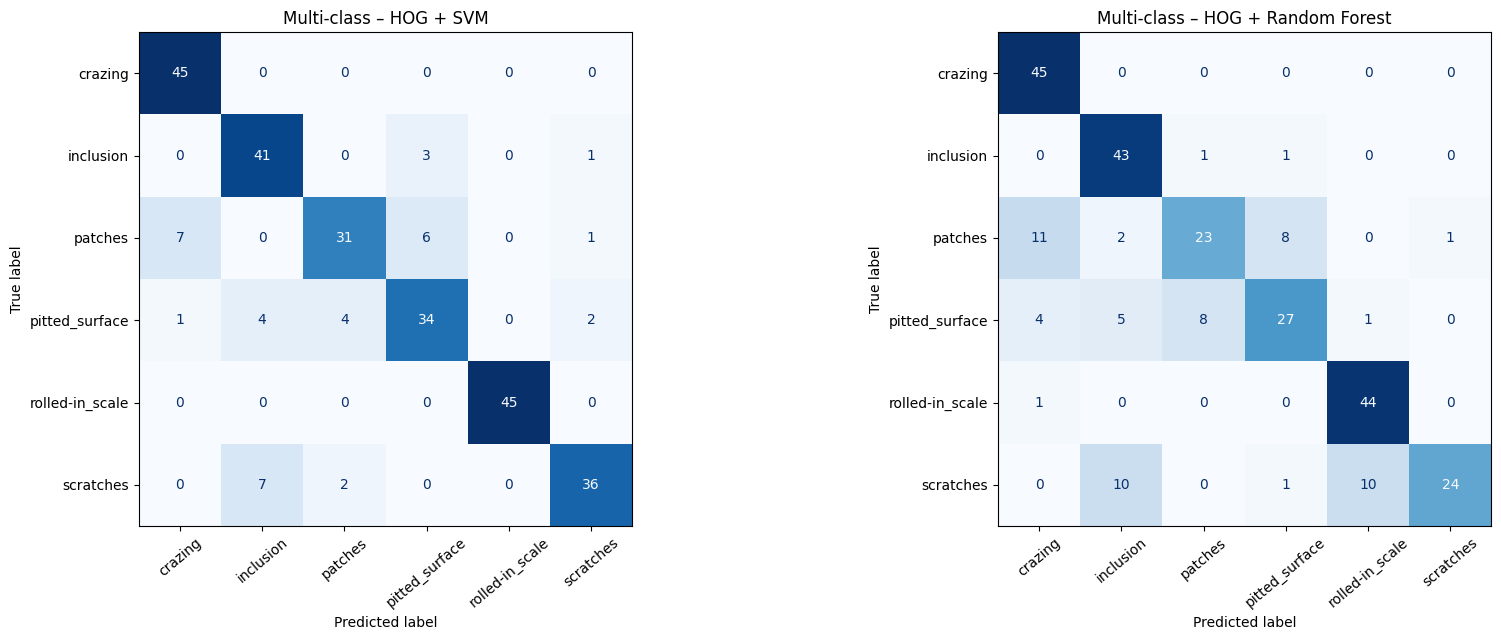


===== Multi-class | HOG + SVM =====
                 precision    recall  f1-score   support

        crazing     0.8491    1.0000    0.9184        45
      inclusion     0.7885    0.9111    0.8454        45
        patches     0.8378    0.6889    0.7561        45
 pitted_surface     0.7907    0.7556    0.7727        45
rolled-in_scale     1.0000    1.0000    1.0000        45
      scratches     0.9000    0.8000    0.8471        45

       accuracy                         0.8593       270
      macro avg     0.8610    0.8593    0.8566       270
   weighted avg     0.8610    0.8593    0.8566       270


===== Multi-class | HOG + Random Forest =====
                 precision    recall  f1-score   support

        crazing     0.7377    1.0000    0.8491        45
      inclusion     0.7167    0.9556    0.8190        45
        patches     0.7188    0.5111    0.5974        45
 pitted_surface     0.7297    0.6000    0.6585        45
rolled-in_scale     0.8000    0.9778    0.8800        45


In [10]:
for task, y, labels in [("Binary", y_bin, ["Non-Defective", "Defective"]),
                        ("Multi-class", y_multi, CLASS_NAMES)]:
    fig, axes = plt.subplots(1, 2, figsize=(14 if task == "Binary" else 18, 5.5 if task == "Binary" else 6.5))
    for ax, name in zip(axes, ["HOG + SVM", "HOG + Random Forest"]):
        _, pred = trained[(task, name)]
        ConfusionMatrixDisplay(confusion_matrix(y[te], pred), display_labels=labels).plot(
            ax=ax, cmap="Blues", colorbar=False, xticks_rotation=40)
        ax.set_title(f"{task} – {name}")
    plt.tight_layout(); plt.show()

    for name in ["HOG + SVM", "HOG + Random Forest"]:
        _, pred = trained[(task, name)]
        print(f"\n===== {task} | {name} =====")
        print(classification_report(y[te], pred, target_names=labels, digits=4, zero_division=0))

## 11. HOG parameter study (cell size × orientations)


In [11]:
CELLS = [4, 8, 16]
ORIS  = [6, 9, 12]
grid_rows = []
for cell in CELLS:
    for ori in ORIS:
        t0 = time.time()
        Fg = extract_hog(X_img, cell, ori)
        for name, mk in [("SVM", make_svm), ("Random Forest", make_rf)]:
            m = mk().fit(Fg[tr], y_bin[tr])
            met = get_metrics(y_bin[va], m.predict(Fg[va]), "binary")
            grid_rows.append({"Cell": f"{cell}x{cell}", "Orientations": ori, "Model": name,
                              "Feature dim": Fg.shape[1], **met})
        print(f"cell {cell}x{cell}, ori {ori} done in {time.time()-t0:.0f}s")
grid_df = pd.DataFrame(grid_rows).round(4)
grid_df

cell 4x4, ori 6 done in 170s
cell 4x4, ori 9 done in 165s
cell 4x4, ori 12 done in 179s
cell 8x8, ori 6 done in 40s
cell 8x8, ori 9 done in 50s
cell 8x8, ori 12 done in 55s
cell 16x16, ori 6 done in 14s
cell 16x16, ori 9 done in 20s
cell 16x16, ori 12 done in 20s


,Cell,Orientations,Model,Feature dim,Accuracy,Precision,Recall,F1
0,4x4,6,SVM,23064,0.8778,0.8840,0.9822,0.9305
1,4x4,6,Random Forest,23064,0.8333,0.8333,1.0000,0.9091
2,4x4,9,SVM,34596,0.8333,0.8358,0.9956,0.9087
3,4x4,9,Random Forest,34596,0.8333,0.8333,1.0000,0.9091
4,4x4,12,SVM,46128,0.8333,0.8358,0.9956,0.9087
5,4x4,12,Random Forest,46128,0.8333,0.8333,1.0000,0.9091
6,8x8,6,SVM,5400,0.9667,0.9954,0.9644,0.9797
7,8x8,6,Random Forest,5400,0.8741,0.8716,0.9956,0.9295
8,8x8,9,SVM,8100,0.9556,0.9819,0.9644,0.9731
9,8x8,9,Random Forest,8100,0.8444,0.8479,0.9911,0.9139


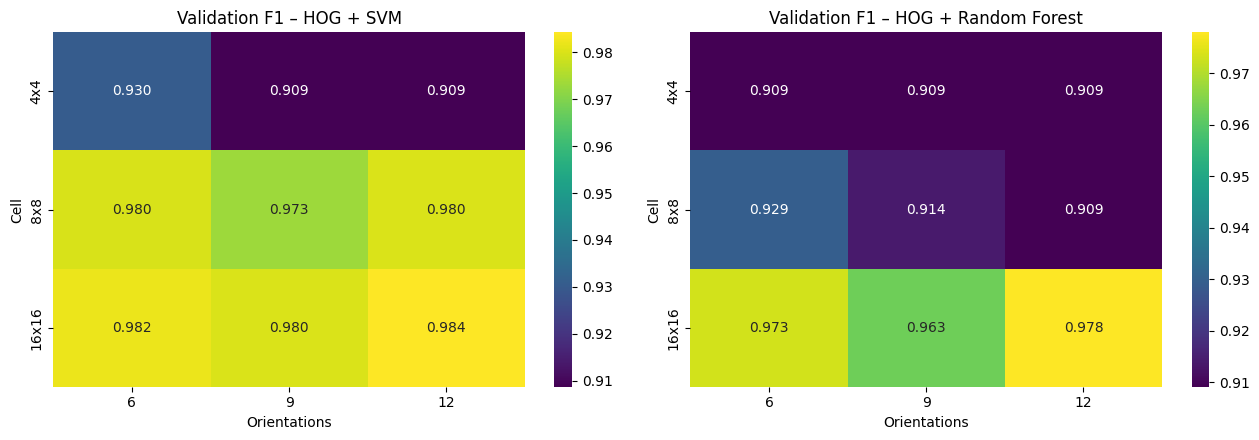

Best HOG configuration for SVM (by validation F1): cell 16x16, 12 orientations


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, name in zip(axes, ["SVM", "Random Forest"]):
    pv = grid_df[grid_df.Model == name].pivot(index="Cell", columns="Orientations", values="F1")
    pv = pv.loc[[f"{c}x{c}" for c in CELLS]]
    sns.heatmap(pv, annot=True, fmt=".3f", cmap="viridis", ax=ax)
    ax.set_title(f"Validation F1 – HOG + {name}")
plt.tight_layout(); plt.show()

best = grid_df[grid_df.Model == "SVM"].sort_values("F1", ascending=False).iloc[0]
BEST_CELL = int(best.Cell.split("x")[0]); BEST_ORI = int(best.Orientations)
print(f"Best HOG configuration for SVM (by validation F1): cell {BEST_CELL}x{BEST_CELL}, {BEST_ORI} orientations")

### Final models with the best HOG parameters (evaluated on the test set)

In [13]:
F_best = extract_hog(X_img, BEST_CELL, BEST_ORI)

final_svm = make_svm(prob=True).fit(F_best[tr], y_bin[tr])      # probability=True -> confidence score
final_rf  = make_rf().fit(F_best[tr], y_bin[tr])

final_rows = []
for name, m in [("HOG + SVM", final_svm), ("HOG + Random Forest", final_rf)]:
    final_rows.append({"Model": name, **get_metrics(y_bin[te], m.predict(F_best[te]), "binary")})
pd.DataFrame(final_rows).round(4)

,Model,Accuracy,Precision,Recall,F1
0,HOG + SVM,0.9889,1.000,0.9867,0.9933
1,HOG + Random Forest,0.9778,0.991,0.9822,0.9866


               precision    recall  f1-score   support

Non-Defective     0.9375    1.0000    0.9677        45
    Defective     1.0000    0.9867    0.9933       225

     accuracy                         0.9889       270
    macro avg     0.9688    0.9933    0.9805       270
 weighted avg     0.9896    0.9889    0.9890       270



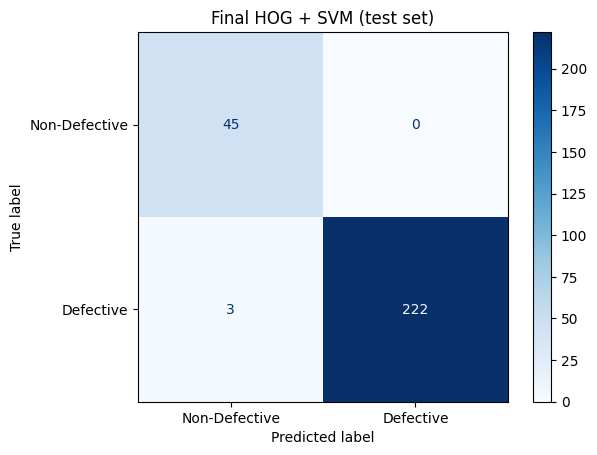

['hog_qc_model.joblib']

In [14]:
print(classification_report(y_bin[te], final_svm.predict(F_best[te]),
                            target_names=["Non-Defective", "Defective"], digits=4))
ConfusionMatrixDisplay(confusion_matrix(y_bin[te], final_svm.predict(F_best[te])),
                       display_labels=["Non-Defective", "Defective"]).plot(cmap="Blues")
plt.title("Final HOG + SVM (test set)"); plt.show()

# Save model for the real-time demo
joblib.dump({"model": final_svm, "cell": BEST_CELL, "ori": BEST_ORI, "img_size": IMG_SIZE},
            "hog_qc_model.joblib")

## 12. Robustness experiment


In [15]:
def brightness(img, f):
    return np.clip(img.astype(np.float32) * f, 0, 255).astype(np.uint8)

def gaussian_noise(img, sigma):
    rng = np.random.default_rng(SEED)
    return np.clip(img.astype(np.float32) + rng.normal(0, sigma, img.shape), 0, 255).astype(np.uint8)

def rotate(img, angle):
    h, w = img.shape
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)

def blur(img, sigma):
    return cv2.GaussianBlur(img, (0, 0), sigma)

conditions = {
    "Original":              lambda x: x,
    "Brightness x0.6 (dark)":   lambda x: brightness(x, 0.6),
    "Brightness x1.4 (bright)": lambda x: brightness(x, 1.4),
    "Noise sigma=10":        lambda x: gaussian_noise(x, 10),
    "Noise sigma=25":        lambda x: gaussian_noise(x, 25),
    "Rotation 10 deg":       lambda x: rotate(x, 10),
    "Rotation 30 deg":       lambda x: rotate(x, 30),
    "Blur sigma=1":          lambda x: blur(x, 1),
    "Blur sigma=2":          lambda x: blur(x, 2),
}

def robustness_table(model):
    rows = []
    for cname, fn in conditions.items():
        Xp = np.array([fn(x) for x in X_img[te]])
        Fp = extract_hog(Xp, BEST_CELL, BEST_ORI)
        met = get_metrics(y_bin[te], model.predict(Fp), "binary")
        rows.append({"Condition": cname, "Accuracy": met["Accuracy"], "F1": met["F1"]})
    out = pd.DataFrame(rows)
    out["dAcc"] = out.Accuracy - out.Accuracy.iloc[0]
    out["dF1"]  = out.F1 - out.F1.iloc[0]
    return out.round(4)

rob_df = robustness_table(final_svm)
rob_df

,Condition,Accuracy,F1,dAcc,dF1
0,Original,0.9889,0.9933,0.0000,0.0000
1,Brightness x0.6 (dark),0.9741,0.9847,-0.0148,-0.0086
2,Brightness x1.4 (bright),0.9296,0.9591,-0.0593,-0.0341
3,Noise sigma=10,0.4111,0.4536,-0.5778,-0.5397
4,Noise sigma=25,0.2296,0.1405,-0.7593,-0.8528
5,Rotation 10 deg,0.9630,0.9783,-0.0259,-0.0150
6,Rotation 30 deg,0.9037,0.9454,-0.0852,-0.0479
7,Blur sigma=1,0.8333,0.9091,-0.1556,-0.0842
8,Blur sigma=2,0.8333,0.9091,-0.1556,-0.0842


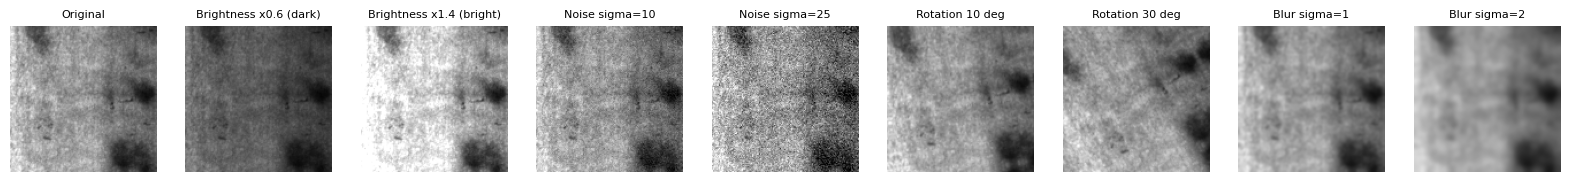

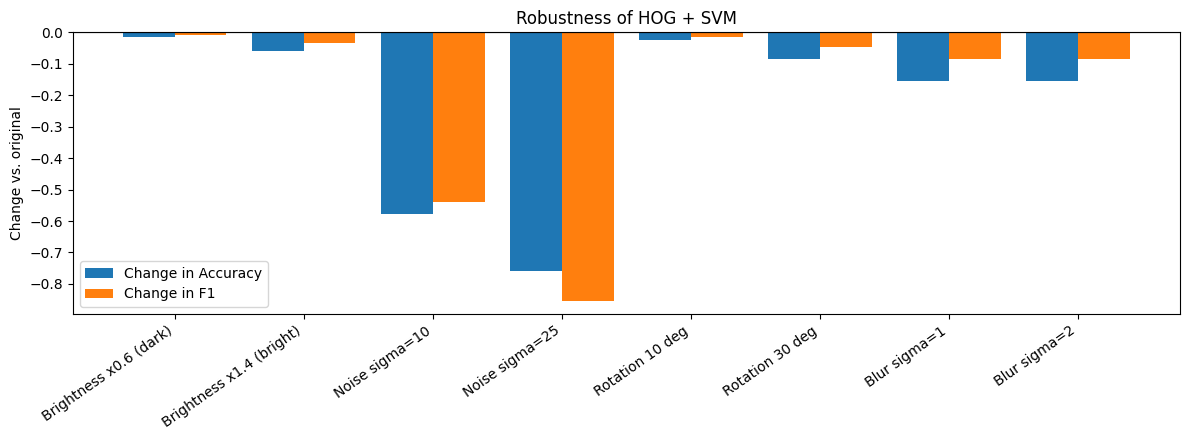

In [16]:
# Visual examples of the perturbations
i = te[0]
fig, axes = plt.subplots(1, len(conditions), figsize=(20, 2.8))
for ax, (cname, fn) in zip(axes, conditions.items()):
    ax.imshow(fn(X_img[i]), cmap="gray", vmin=0, vmax=255); ax.set_title(cname, fontsize=8); ax.axis("off")
plt.show()

plot_df = rob_df.iloc[1:]
x = np.arange(len(plot_df)); w = 0.4
plt.figure(figsize=(12, 4.5))
plt.bar(x - w/2, plot_df.dAcc, w, label="Change in Accuracy")
plt.bar(x + w/2, plot_df.dF1,  w, label="Change in F1")
plt.xticks(x, plot_df.Condition, rotation=35, ha="right"); plt.axhline(0, color="k", lw=0.8)
plt.ylabel("Change vs. original"); plt.title("Robustness of HOG + SVM"); plt.legend(); plt.tight_layout(); plt.show()

In [17]:
# (Optional improvement) Retrain with augmented training images and compare robustness
aug_fns = [conditions[k] for k in ["Brightness x0.6 (dark)", "Brightness x1.4 (bright)",
                                   "Noise sigma=10", "Rotation 10 deg", "Blur sigma=1"]]
X_aug  = np.concatenate([X_img[tr]] + [np.array([fn(x) for x in X_img[tr]]) for fn in aug_fns])
y_aug  = np.concatenate([y_bin[tr]] * (1 + len(aug_fns)))
svm_aug = make_svm(prob=True).fit(extract_hog(X_aug, BEST_CELL, BEST_ORI), y_aug)

cmp = rob_df[["Condition", "Accuracy", "F1"]].merge(
    robustness_table(svm_aug)[["Condition", "Accuracy", "F1"]],
    on="Condition", suffixes=(" (normal training)", " (augmented training)"))
cmp

,Condition,Accuracy (normal training),F1 (normal training),Accuracy (augmented training),F1 (augmented training)
0,Original,0.9889,0.9933,0.9556,0.9729
1,Brightness x0.6 (dark),0.9741,0.9847,0.9667,0.9799
2,Brightness x1.4 (bright),0.9296,0.9591,0.9333,0.9596
3,Noise sigma=10,0.4111,0.4536,0.9259,0.9559
4,Noise sigma=25,0.2296,0.1405,0.8407,0.9128
5,Rotation 10 deg,0.9630,0.9783,0.9630,0.9776
6,Rotation 30 deg,0.9037,0.9454,0.9519,0.9713
7,Blur sigma=1,0.8333,0.9091,0.9444,0.9675
8,Blur sigma=2,0.8333,0.9091,0.8519,0.9184


## 13. Industrial quality-control decision module

--- True class: NON-DEFECTIVE (crazing) ---
PRODUCT INSPECTION RESULT
Prediction: NON-DEFECTIVE
Confidence: 87.6%
Action: ACCEPT PRODUCT



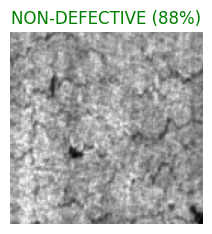

--- True class: DEFECTIVE (patches) ---
PRODUCT INSPECTION RESULT
Prediction: NON-DEFECTIVE
Confidence: 50.0%
Action: ACCEPT PRODUCT



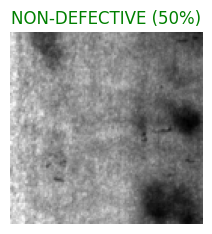

In [18]:
def inspect_product(image, model=final_svm, cell=BEST_CELL, ori=BEST_ORI, show=True):
    """image: file path or numpy array. Prints the inspection report and returns the decision."""
    img = cv2.imread(image, cv2.IMREAD_COLOR) if isinstance(image, str) else image
    g = preprocess(img)
    feat = hog_feat(g, cell, ori).reshape(1, -1)
    proba = model.predict_proba(feat)[0]          # [P(non-defective), P(defective)]
    pred = int(np.argmax(proba)); conf = proba[pred] * 100
    label  = "DEFECTIVE" if pred == 1 else "NON-DEFECTIVE"
    action = "REJECT PRODUCT" if pred == 1 else "ACCEPT PRODUCT"
    print("PRODUCT INSPECTION RESULT")
    print(f"Prediction: {label}")
    print(f"Confidence: {conf:.1f}%")
    print(f"Action: {action}\n")
    if show:
        plt.figure(figsize=(2.5, 2.5)); plt.imshow(g, cmap="gray"); plt.axis("off")
        plt.title(f"{label} ({conf:.0f}%)", color="red" if pred else "green"); plt.show()
    return label, conf, action

# Demo on one test image from each binary class
for cls in [0, 1]:
    k = te[np.where(y_bin[te] == cls)[0][0]]
    print(f"--- True class: {'DEFECTIVE' if cls else 'NON-DEFECTIVE'} ({df.label[k]}) ---")
    inspect_product(df.path[k])

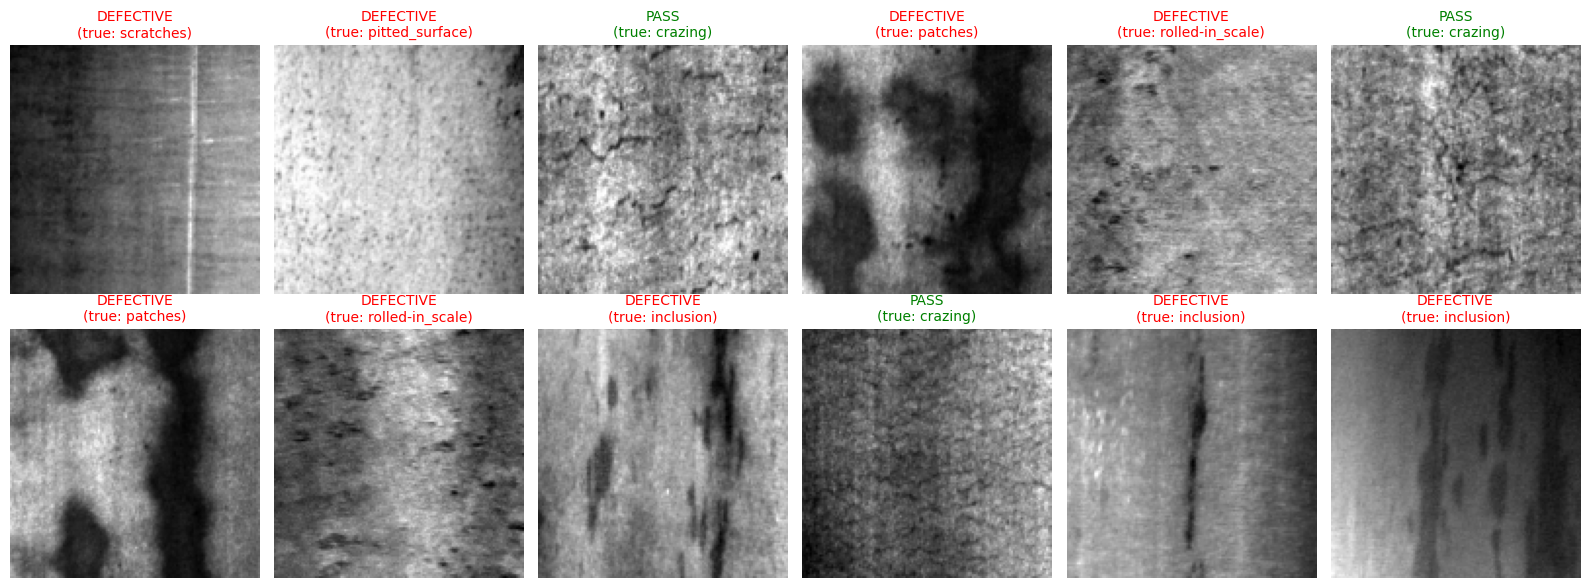

In [19]:
# Simulated production line: 12 random test items with PASS / DEFECTIVE overlay
sel = np.random.default_rng(1).choice(te, 12, replace=False)
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
for ax, k in zip(axes.ravel(), sel):
    f = hog_feat(X_img[k], BEST_CELL, BEST_ORI).reshape(1, -1)
    p = final_svm.predict(f)[0]
    ax.imshow(X_img[k], cmap="gray"); ax.axis("off")
    ax.set_title(("DEFECTIVE" if p else "PASS") + f"\n(true: {df.label[k]})",
                 color="red" if p else "green", fontsize=10)
plt.tight_layout(); plt.show()

## Bonus: real-time webcam / video prototype
Colab cannot open a local webcam through `cv2.VideoCapture`, so the cell below writes a standalone script. Download `hog_qc_model.joblib` and `realtime_inspection.py` and run on your laptop:
`python realtime_inspection.py` (webcam) or `python realtime_inspection.py video.mp4`. Press **q** to quit.
(`pip install opencv-python scikit-image scikit-learn joblib`)

In [20]:
%%writefile realtime_inspection.py
import sys, cv2, joblib, numpy as np
from skimage.feature import hog

bundle = joblib.load("hog_qc_model.joblib")
model, CELL, ORI, SIZE = bundle["model"], bundle["cell"], bundle["ori"], bundle["img_size"]

src = sys.argv[1] if len(sys.argv) > 1 else 0
cap = cv2.VideoCapture(src)
while cap.isOpened():
    ok, frame = cap.read()
    if not ok:
        break
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape; s = min(h, w)                         # centre crop (inspection region)
    y0, x0 = (h - s) // 2, (w - s) // 2
    roi = cv2.resize(gray[y0:y0 + s, x0:x0 + s], (SIZE, SIZE), interpolation=cv2.INTER_AREA)
    feat = hog(roi, orientations=ORI, pixels_per_cell=(CELL, CELL),
               cells_per_block=(2, 2), block_norm="L2-Hys").reshape(1, -1)
    proba = model.predict_proba(feat)[0]
    defective = proba[1] >= 0.5
    text = f"{'DEFECTIVE' if defective else 'PASS'} ({max(proba)*100:.0f}%)"
    color = (0, 0, 255) if defective else (0, 200, 0)
    cv2.rectangle(frame, (x0, y0), (x0 + s, y0 + s), color, 3)
    cv2.putText(frame, text, (20, 45), cv2.FONT_HERSHEY_SIMPLEX, 1.2, color, 3)
    cv2.imshow("HOG Industrial Inspection", frame)
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break
cap.release(); cv2.destroyAllWindows()

Writing realtime_inspection.py


In [21]:
from google.colab import files
files.download("hog_qc_model.joblib"); files.download("realtime_inspection.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Report guide (3–5 pages)
Use the tables/figures generated above.

| Section | What to write / which output to use |
|---|---|
| 1. Introduction | Manual inspection is slow and error-prone; goal = automated HOG-based inspection |
| 2. Industrial Application | Steel-strip surface inspection in rolling mills; accept/reject on the line |
| 3. Dataset | NEU-DET: 1800 grayscale 200×200 images, 6 defect classes, 300 each; class-count table; sample figure; **state the Normal-class assumption** |
| 4. Preprocessing | BGR→grayscale, resize to 128×128 (INTER_AREA), stratified 70/15/15 split |
| 5. HOG | Cells, orientation bins, 2×2 block L2-Hys normalisation; HOG visualisation figure; feature-vector length |
| 6. Classification | SVM (RBF, C=10, standardised, balanced weights) and Random Forest (300 trees) |
| 7. Experimental Setup | Split, metrics (Acc/Prec/Rec/F1), parameter grid 3×3, Colab CPU |
| 8. Results | Model comparison table, confusion matrices, classification reports, parameter heat-maps |
| 9. Robustness | Robustness table + bar chart (ΔAccuracy, ΔF1); augmentation comparison |
| 10. Deployment | Fixed camera + lighting, edge device, latency, confidence threshold → manual review band |
| 11. Limitations | No true normal class, small dataset, HOG not rotation-invariant, handcrafted features vs. CNNs, lab vs. factory conditions |
| 12. Conclusion | Best configuration, key numbers, future work (CNN, anomaly detection, rotation-augmented training) |